# Detection Statistique (Clustering DBSCAN)

UTILISER CETTE VERSION.
VERIFIER LA COHERENCE DES RESULTATS

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [17]:
import pandas as pd
df_clear = pd.read_csv("farm_array_elec_clearsky.csv")
print(df_clear.columns.tolist())
print(df_clear.head())

['Unnamed: 0', 'measured_on', 'inv_01_dc_current', 'inv_01_dc_voltage', 'inv_01_ac_current', 'inv_01_ac_voltage', 'inv_01_ac_power', 'inv_02_dc_current', 'inv_02_dc_voltage', 'inv_02_ac_current', 'inv_02_ac_voltage', 'inv_02_ac_power', 'inv_03_dc_current', 'inv_03_dc_voltage', 'inv_03_ac_current', 'inv_03_ac_voltage', 'inv_03_ac_power', 'inv_05_dc_current', 'inv_05_ac_current', 'inv_05_ac_voltage', 'inv_05_ac_power', 'inv_06_dc_current', 'inv_06_dc_voltage', 'inv_06_ac_current', 'inv_06_ac_voltage', 'inv_06_ac_power', 'inv_07_dc_current', 'inv_07_dc_voltage', 'inv_07_ac_current', 'inv_07_ac_voltage', 'inv_07_ac_power', 'inv_08_dc_current', 'inv_08_dc_voltage', 'inv_08_ac_current', 'inv_08_ac_voltage', 'inv_08_ac_power', 'inv_09_dc_current', 'inv_09_dc_voltage', 'inv_09_ac_current', 'inv_09_ac_voltage', 'inv_09_ac_power', 'inv_10_dc_current', 'inv_10_dc_voltage', 'inv_10_ac_current', 'inv_10_ac_voltage', 'inv_10_ac_power', 'inv_11_dc_current', 'inv_11_dc_voltage', 'inv_11_ac_current', '

## Configuration

In [18]:
# Paramètres de détection
ANOMALY_THRESHOLD = 0.15  # 15% d'écart minimum vs référence
MIN_DURATION = 30  # Minutes consécutives minimum
RECURRENCE_THRESHOLD = 0.60  # 60% de jours avec anomalie = motif récurrent
MIN_POWER_THRESHOLD = 100  # W - Seuil minimum pour analyse (évite nuit)

# Paramètres DBSCAN
DBSCAN_EPS_DAYS = 12  # Tolérance temporelle (jours)
DBSCAN_MIN_SAMPLES = 6  # Minimum de jours pour former un cluster
DBSCAN_EPS_HOURS = 0.5  # Tolérance horaire (heures)

# Paramètres saisonniers
SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11]
}

print("🔍 Chargement des données prétraitées...")

🔍 Chargement des données prétraitées...


## Chargement et préparation des données

In [19]:
df_clear = pd.read_csv("farm_array_elec_clearsky.csv")

# Renommage de la colonne temporelle
if 'measured_on' in df_clear.columns:
    df_clear['timestamp'] = pd.to_datetime(df_clear['measured_on'])
elif 'timestamp' not in df_clear.columns:
    raise ValueError("Aucune colonne temporelle trouvée (measured_on ou timestamp)")

df_clear = df_clear.sort_values('timestamp').reset_index(drop=True)

# Détection des onduleurs (colonnes inv_XX_ac_power)
power_cols = [c for c in df_clear.columns if c.endswith('_ac_power') and c.startswith('inv_')]
inverter_ids = [c.replace('_ac_power', '') for c in power_cols]

print(f"✓ {len(df_clear)} lignes chargées")
print(f"✓ {len(power_cols)} onduleurs détectés: {inverter_ids[:5]}{'...' if len(inverter_ids) > 5 else ''}")
print(f"✓ Période: {df_clear['timestamp'].min()} → {df_clear['timestamp'].max()}")

if len(power_cols) == 0:
    raise ValueError("❌ Aucune colonne *_ac_power trouvée!")

# Filtrage des valeurs aberrantes et nettoyage
for col in power_cols:
    df_clear[col] = pd.to_numeric(df_clear[col], errors='coerce').fillna(0)
    df_clear[col] = df_clear[col].clip(lower=0)  # Pas de puissance négative

✓ 721067 lignes chargées
✓ 23 onduleurs détectés: ['inv_01', 'inv_02', 'inv_03', 'inv_05', 'inv_06']...
✓ Période: 2017-11-01 00:00:00 → 2024-11-01 23:55:00


## Calcul du panneau de référence 

In [20]:
# Identify power columns
power_cols = [col for col in df_clear.columns if 'ac_power' in col and 'inv' in col]
print(f"📊 Found {len(power_cols)} inverter power channels")
print(f"   Analyzing clear-sky data: {len(df_clear):,} points")

# Calculate correlation matrix between all inverters
print("\n🔍 Analyzing inter-inverter correlations...")
corr_matrix = df_clear[power_cols].corr()

# Calculate average correlation for each inverter (excluding self-correlation)
corr_sums = corr_matrix.sum().sort_values(ascending=False)
corr_avg = (corr_sums - 1) / (len(power_cols) - 1)  # Subtract 1 to exclude self-correlation

# Select the inverter with highest average correlation
reference_inv = corr_sums.index[0]

print(f"\n{'='*70}")
print(f"SELECTED REFERENCE PANEL: {reference_inv}")
print(f"{'='*70}")
print(f"Average correlation: {corr_avg.iloc[0]:.4f}")
print(f"Min correlation: {corr_matrix[reference_inv].drop(reference_inv).min():.4f}")
print(f"Max correlation: {corr_matrix[reference_inv].drop(reference_inv).max():.4f}")

📊 Found 23 inverter power channels
   Analyzing clear-sky data: 721,067 points

🔍 Analyzing inter-inverter correlations...

SELECTED REFERENCE PANEL: inv_11_ac_power
Average correlation: 0.9519
Min correlation: 0.8955
Max correlation: 0.9882


In [21]:
# Select top N most correlated panels as reference candidates
N_REFERENCE_PANELS = 5  # Number of top panels to use for correction
top_panels = corr_avg.head(N_REFERENCE_PANELS).index.tolist()

print(f"🔧 Creating corrected reference using top {N_REFERENCE_PANELS} panels:")
for i, panel in enumerate(top_panels, 1):
    print(f"   {i}. {panel} (avg corr: {corr_avg.loc[panel]:.4f})")

# Create ensemble reference (median of top N panels)
df_clear['reference_ensemble'] = df_clear[top_panels].median(axis=1)

print(f"\n✅ Ensemble reference created from {N_REFERENCE_PANELS} panels")

🔧 Creating corrected reference using top 5 panels:
   1. inv_11_ac_power (avg corr: 0.9519)
   2. inv_20_ac_power (avg corr: 0.9516)
   3. inv_22_ac_power (avg corr: 0.9489)
   4. inv_12_ac_power (avg corr: 0.9488)
   5. inv_13_ac_power (avg corr: 0.9483)

✅ Ensemble reference created from 5 panels


In [22]:
def create_corrected_reference(df, primary_ref, top_panels, sigma_threshold=3.0):
    """
    Create a corrected reference by detecting and replacing anomalies in the primary reference.
    
    Parameters:
    -----------
    df : DataFrame
        Clear-sky filtered data
    primary_ref : str
        Primary reference panel column name
    top_panels : list
        List of top N panel column names (including primary)
    sigma_threshold : float
        Threshold for anomaly detection in primary reference
    
    Returns:
    --------
    tuple: (corrected_reference_series, correction_info_dict)
    """
    # Start with primary reference
    ref_corrected = df[primary_ref].copy()
    
    # Calculate ensemble reference (median of top N)
    ensemble_ref = df[top_panels].median(axis=1)
    
    # Detect anomalies in primary reference by comparing to ensemble
    # Calculate the ratio: primary / ensemble
    ratio = ref_corrected / ensemble_ref
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    
    # Use robust statistics for anomaly detection
    median_ratio = ratio.median()
    mad = np.median(np.abs(ratio - median_ratio))
    std_estimate = 1.4826 * mad
    
    # Define thresholds (both upper and lower bounds)
    lower_threshold = median_ratio - sigma_threshold * std_estimate
    upper_threshold = median_ratio + sigma_threshold * std_estimate
    
    # Identify anomalies (deviations from expected behavior)
    anomalies = (ratio < lower_threshold) | (ratio > upper_threshold)
    n_anomalies = anomalies.sum()
    
    # Replace anomalous values with ensemble median
    ref_corrected[anomalies] = ensemble_ref[anomalies]
    
    correction_info = {
        'n_corrections': n_anomalies,
        'correction_pct': n_anomalies / len(df) * 100,
        'median_ratio': median_ratio,
        'lower_threshold': lower_threshold,
        'upper_threshold': upper_threshold,
        'anomaly_mask': anomalies
    }
    
    return ref_corrected, correction_info

# Create corrected reference
reference_corrected, correction_info = create_corrected_reference(
    df_clear, 
    reference_inv, 
    top_panels,
    sigma_threshold=3.0
)

df_clear['reference_corrected'] = reference_corrected

print(f"\n📊 Reference Correction Statistics:")
print(f"   Anomalies detected: {correction_info['n_corrections']:,} points ({correction_info['correction_pct']:.3f}%)")
print(f"   Median ratio (primary/ensemble): {correction_info['median_ratio']:.4f}")
print(f"   Threshold range: [{correction_info['lower_threshold']:.4f}, {correction_info['upper_threshold']:.4f}]")

if correction_info['n_corrections'] > 0:
    print(f"   ✅ Corrected reference created with {correction_info['n_corrections']} points adjusted")
else:
    print(f"   ✅ Primary reference is clean - no corrections needed")


📊 Reference Correction Statistics:
   Anomalies detected: 0 points (0.000%)
   Median ratio (primary/ensemble): 0.9997
   Threshold range: [nan, nan]
   ✅ Primary reference is clean - no corrections needed


# A adapter en dessous !

## Etape 1 : Détection des outliers par ondulateurs 

In [23]:
MIN_POWER_THRESHOLD_ADJUSTED = float(MIN_POWER_THRESHOLD / 1000)

In [24]:
# Détection des anomalies - VERSION SIMPLIFIÉE (comparaison directe à reference_corrected)

print(f"\n🔍 Détection des anomalies (seuil: {ANOMALY_THRESHOLD:.1%})...")

# Préparation du DataFrame pour l'analyse
df_ratios = df_clear[['timestamp', 'hour', 'date', 'reference_corrected']].copy()

# Masque pour filtrer les périodes de production significative
mask_daylight = df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED

print(f"\n📊 Périodes analysées:")
print(f"  Points valides (production): {mask_daylight.sum():,} / {len(df_clear):,} ({mask_daylight.sum()/len(df_clear)*100:.1f}%)")

if mask_daylight.sum() == 0:
    raise ValueError("❌ Aucune période de production détectée. Vérifiez MIN_POWER_THRESHOLD_ADJUSTED ou les données.")

# Détection des anomalies pour chaque onduleur
anomalies = []
print(f"\n🔎 Analyse onduleur par onduleur:")

for inv_id, power_col in zip(inverter_ids, power_cols):
    
    # Calcul de la perte relative par rapport à reference_corrected
    # loss_pct = (référence - réel) / référence
    # Exemple: si référence=100W et onduleur=70W → loss_pct = 30% = 0.30
    loss_pct = np.where(
        df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED,
        (df_clear['reference_corrected'] - df_clear[power_col]) / df_clear['reference_corrected'],
        0.0
    )
    loss_pct = np.clip(loss_pct, 0, 1.0)  # Entre 0% et 100%
    
    # Stockage pour analyse ultérieure
    df_ratios[f'loss_{inv_id}'] = loss_pct
    
    # Masque d'anomalie: perte > seuil ET production significative
    mask_anomaly = (loss_pct > ANOMALY_THRESHOLD) & mask_daylight
    
    # Statistiques de cet onduleur
    if mask_daylight.sum() > 0:
        avg_loss_daylight = loss_pct[mask_daylight].mean()
        max_loss_daylight = loss_pct[mask_daylight].max()
        
        if mask_anomaly.sum() > 0:
            avg_loss_anomaly = loss_pct[mask_anomaly].mean()
            print(f"  {inv_id}: {mask_anomaly.sum():>6} anomalies | "
                  f"Perte moy totale: {avg_loss_daylight:>5.1%} | "
                  f"Perte moy anomalies: {avg_loss_anomaly:>5.1%} | "
                  f"Perte max: {max_loss_daylight:>5.1%}")
    
    # Regroupement en séquences continues (durée minimale)
    df_temp = pd.DataFrame({
        'timestamp': df_clear['timestamp'],
        'anomaly': mask_anomaly,
        'loss_pct': loss_pct
    })
    
    df_temp['anomaly_group'] = (df_temp['anomaly'] != df_temp['anomaly'].shift()).cumsum()
    
    for group_id, group in df_temp[df_temp['anomaly']].groupby('anomaly_group'):
        duration_minutes = len(group) * 5  # Intervalle de 5 minutes
        
        if duration_minutes >= MIN_DURATION:
            anomalies.append({
                'inverter_id': inv_id,
                'start_time': group['timestamp'].iloc[0],
                'end_time': group['timestamp'].iloc[-1],
                'duration_min': duration_minutes,
                'avg_deviation': group['loss_pct'].mean(),
                'max_deviation': group['loss_pct'].max()
            })

# Création du DataFrame des anomalies
df_anomalies = pd.DataFrame(anomalies)

print(f"\n{'='*70}")
if len(df_anomalies) == 0:
    print("⚠️  Aucune anomalie détectée avec les seuils actuels")
    print(f"💡 Suggestions:")
    print(f"  - Réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD:.1%})")
    print(f"  - Réduire MIN_DURATION (actuellement {MIN_DURATION} min)")
    print(f"  - Vérifier que reference_corrected est correctement calculée")
else:
    print(f"✅ RÉSULTATS DÉTECTION:")
    print(f"  • {len(df_anomalies):,} périodes d'anomalie détectées")
    print(f"  • {df_anomalies['inverter_id'].nunique()} onduleurs concernés")
    print(f"  • Durée totale: {df_anomalies['duration_min'].sum():,.0f} minutes")
    print(f"  • Perte moyenne: {df_anomalies['avg_deviation'].mean():.1%}")
    print(f"  • Perte maximale: {df_anomalies['max_deviation'].max():.1%}")
    
    print(f"\n📊 Top 5 onduleurs les plus affectés:")
    top_affected = df_anomalies.groupby('inverter_id').agg({
        'duration_min': 'sum',
        'avg_deviation': 'mean'
    }).sort_values('duration_min', ascending=False).head(5)
    
    for inv, row in top_affected.iterrows():
        print(f"  {inv}: {row['duration_min']:>8,.0f} min | Perte moy: {row['avg_deviation']:>5.1%}")



🔍 Détection des anomalies (seuil: 15.0%)...

📊 Périodes analysées:
  Points valides (production): 335,495 / 721,067 (46.5%)

🔎 Analyse onduleur par onduleur:
  inv_01:  76894 anomalies | Perte moy totale: 10.2% | Perte moy anomalies: 41.4% | Perte max: 100.0%
  inv_02: 114079 anomalies | Perte moy totale: 17.0% | Perte moy anomalies: 46.7% | Perte max: 100.0%
  inv_03:  73088 anomalies | Perte moy totale:  8.7% | Perte moy anomalies: 33.3% | Perte max: 100.0%
  inv_05:  64864 anomalies | Perte moy totale:  8.7% | Perte moy anomalies: 39.5% | Perte max: 100.0%
  inv_06:  85700 anomalies | Perte moy totale: 14.3% | Perte moy anomalies: 51.8% | Perte max: 100.0%
  inv_07:  68423 anomalies | Perte moy totale: 14.4% | Perte moy anomalies: 66.2% | Perte max: 100.0%
  inv_08:  42874 anomalies | Perte moy totale:  7.5% | Perte moy anomalies: 48.0% | Perte max: 100.0%
  inv_09:  29397 anomalies | Perte moy totale:  3.2% | Perte moy anomalies: 32.2% | Perte max: 100.0%
  inv_10:  41046 anomalie

- `df_anomalies` contient les périodes où un onduleur est significativement en dessous du comportement attendu (seuil `ANOMALY_THRESHOLD`, durée ≥ `MIN_DURATION`).
- Un grand nombre d'anomalies courtes peut indiquer du bruit (nuages transitoires, capteurs, erreurs de données).
- Des anomalies longues et récurrentes suggèrent un ombrage récurrent ou un problème matériel.


## Etape 2 : Profils horaires (shadox profiles)

In [25]:
# Initialisation AVANT la condition
df_profiles = pd.DataFrame()
profiles = []

if len(df_anomalies) > 0:
    # Extraction des caractéristiques temporelles
    df_anomalies['date'] = df_anomalies['start_time'].dt.date
    df_anomalies['hour'] = df_anomalies['start_time'].dt.hour
    df_anomalies['minute'] = df_anomalies['start_time'].dt.minute
    df_anomalies['time_decimal'] = df_anomalies['hour'] + df_anomalies['minute']/60
    df_anomalies['month'] = df_anomalies['start_time'].dt.month
    df_anomalies['day_of_year'] = df_anomalies['start_time'].dt.dayofyear
    
    # Attribution des saisons
    def get_season(month):
        for season, months in SEASONS.items():
            if month in months:
                return season
        return 'Unknown'
    
    df_anomalies['season'] = df_anomalies['month'].apply(get_season)
    
    # Calcul de la récurrence
    for (inv, season), group in df_anomalies.groupby(['inverter_id', 'season']):
        total_days = group['date'].nunique()
        
        # Analyse par heure
        for hour in range(24):
            hour_mask = (group['hour'] == hour)
            if hour_mask.sum() > 0:
                recurrence_days = group[hour_mask]['date'].nunique()
                recurrence_rate = recurrence_days / total_days
                
                if recurrence_rate >= RECURRENCE_THRESHOLD:
                    profiles.append({
                        'inverter_id': inv,
                        'season': season,
                        'hour': hour,
                        'recurrence_days': recurrence_days,
                        'total_days': total_days,
                        'recurrence_rate': recurrence_rate,
                        'avg_loss_pct': group[hour_mask]['avg_deviation'].mean() * 100
                    })
    
    df_profiles = pd.DataFrame(profiles)
    print(f"✓ {len(df_profiles)} profils horaires récurrents identifiés")
    
    if len(df_profiles) > 0:
        print("\n📊 Top 5 des profils d'ombrage:")
        display = df_profiles.nlargest(5, 'avg_loss_pct')[
            ['inverter_id', 'season', 'hour', 'recurrence_rate', 'avg_loss_pct']
        ]
        for _, row in display.iterrows():
            print(f"  • {row['inverter_id']} | {row['season']} | {row['hour']:02d}h | "
                  f"Récurrence: {row['recurrence_rate']:.1%} | Perte: {row['avg_loss_pct']:.1f}%")


✓ 38 profils horaires récurrents identifiés

📊 Top 5 des profils d'ombrage:
  • inv_14 | Summer | 06h | Récurrence: 89.1% | Perte: 100.0%
  • inv_17 | Summer | 06h | Récurrence: 74.1% | Perte: 100.0%
  • inv_23 | Summer | 06h | Récurrence: 68.8% | Perte: 96.9%
  • inv_10 | Summer | 06h | Récurrence: 95.0% | Perte: 94.4%
  • inv_24 | Summer | 06h | Récurrence: 67.2% | Perte: 72.1%




**Que contient `df_profiles` ?**
- Profils horaires récurrents d'ombrage par onduleur et saison (heure, taux de récurrence, perte moyenne en %).

**Interprétation**
- Une forte `recurrence_rate` (≥ `RECURRENCE_THRESHOLD`) indique un ombrage régulier à une heure donnée (ex. arbre, obstruction structurelle).
- `avg_loss_pct` permet d'évaluer l'impact énergétique moyen du profil.


## Etape 3 : Clustering saisonier (DBSCAN)

In [26]:
clusters_results = []

if len(df_profiles) > 0:
    for (inv, season), group_profiles in df_profiles.groupby(['inverter_id', 'season']):
        # Extraction des anomalies pour cet onduleur/saison
        mask = (df_anomalies['inverter_id'] == inv) & (df_anomalies['season'] == season)
        season_anomalies = df_anomalies[mask].copy()
        
        if len(season_anomalies) < DBSCAN_MIN_SAMPLES:
            continue
        
        # Features pour DBSCAN
        X = season_anomalies[['day_of_year', 'time_decimal']].values
        
        # Normalisation avec pondération temporelle
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Application DBSCAN
        clustering = DBSCAN(
            eps=0.9,
            min_samples=DBSCAN_MIN_SAMPLES,
            metric='euclidean'
        ).fit(X_scaled)
        
        season_anomalies['cluster'] = clustering.labels_
        
        # Analyse des clusters (exclut bruit: -1)
        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            
            cluster_data = season_anomalies[season_anomalies['cluster'] == cluster_id]
            
            clusters_results.append({
                'inverter_id': inv,
                'season': season,
                'cluster_id': cluster_id,
                'start_date': cluster_data['start_time'].min().date(),
                'end_date': cluster_data['start_time'].max().date(),
                'n_days': cluster_data['date'].nunique(),
                'shadow_start_hour': cluster_data['time_decimal'].min(),
                'shadow_end_hour': cluster_data['time_decimal'].max(),
                'avg_loss_pct': cluster_data['avg_deviation'].mean() * 100,
                'max_loss_pct': cluster_data['max_deviation'].max() * 100
            })

df_clusters = pd.DataFrame(clusters_results)

if len(df_clusters) == 0:
    print("⚠️  Aucun cluster identifié")
    print("💡 Suggestions:")
    print(f"  - Réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD})")
    print(f"  - Réduire RECURRENCE_THRESHOLD (actuellement {RECURRENCE_THRESHOLD})")
    print(f"  - Réduire DBSCAN_MIN_SAMPLES (actuellement {DBSCAN_MIN_SAMPLES})")
else:
    print(f"✓ {len(df_clusters)} clusters d'ombrage identifiés")


✓ 50 clusters d'ombrage identifiés


- DBSCAN groupe des anomalies proches en jour de l'année et heure pour identifier des motifs d'ombrage cohérents (clusters), en excluant le bruit (-1).
- Un cluster indique un motif spatial/temporal répété (ex. ombre d'un mat à certaines périodes).
- `n_days`, `shadow_start_hour`, `avg_loss_pct` donnent l'importance et la fenêtre horaire du problème.


## Etape 4 : Shadow story - rapport final

In [27]:
if len(df_clusters) > 0:
    # Formatage des heures
    def format_hour(decimal_hour):
        h = int(decimal_hour)
        m = int((decimal_hour - h) * 60)
        return f"{h:02d}h{m:02d}"
    
    df_clusters['shadow_period'] = (
        df_clusters['shadow_start_hour'].apply(format_hour) + 
        ' → ' + 
        df_clusters['shadow_end_hour'].apply(format_hour)
    )
    
    # Tri par impact
    df_shadow_story = df_clusters.sort_values('avg_loss_pct', ascending=False)
    
    # Export
    df_shadow_story.to_csv('shadow_storyV3.csv', index=False)
    print("✓ Shadow Story exportée → shadow_storyV3.csv")
    
    print("\n🎯 SHADOW STORY - Top 10 des ombrages critiques:")
    print("="*70)
    for idx, row in df_shadow_story.head(10).iterrows():
        print(f"  {row['inverter_id']:>10} | {row['season']:>6} | {row['shadow_period']} | "
              f"{row['n_days']:3d} jours | Perte: {row['avg_loss_pct']:5.1f}%")
    
    # Visualisations
    
    print("\n📈 Génération des visualisations...")
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Heatmap récurrence horaire
    if len(df_profiles) > 0:
        ax1 = fig.add_subplot(gs[0, :2])
        pivot = df_profiles.pivot_table(
            values='recurrence_rate',
            index='inverter_id',
            columns='hour',
            aggfunc='mean'
        )
        sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0%',
                    cbar_kws={'label': 'Taux de récurrence'}, ax=ax1)
        ax1.set_title('Récurrence Horaire des Ombrages par Onduleur', fontweight='bold')
        ax1.set_xlabel('Heure de la journée')
        ax1.set_ylabel('Onduleur')
    
    # Plot 2: Distribution des pertes
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(df_clusters['avg_loss_pct'], bins=20, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(df_clusters['avg_loss_pct'].median(), color='red', 
                linestyle='--', linewidth=2, label=f"Médiane: {df_clusters['avg_loss_pct'].median():.1f}%")
    ax2.set_title('Distribution des Pertes', fontweight='bold')
    ax2.set_xlabel('Perte moyenne (%)')
    ax2.set_ylabel('Nombre de clusters')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Timeline des périodes d'ombrage
    ax3 = fig.add_subplot(gs[1, :])
    colors = plt.cm.Set3(np.linspace(0, 1, len(df_clusters)))
    for idx, (i, row) in enumerate(df_clusters.iterrows()):
        start = pd.Timestamp(row['start_date'])
        end = pd.Timestamp(row['end_date'])
        ax3.barh(row['inverter_id'], (end - start).days, left=start, 
                height=0.6, color=colors[idx], alpha=0.8, edgecolor='black')
    ax3.set_title('Périodes d\'Ombrage Détectées (Timeline)', fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Onduleur')
    ax3.grid(axis='x', alpha=0.3)
    
    # Plot 4: Scatter clustering (jour vs heure)
    if 'cluster' in df_anomalies.columns:
        ax4 = fig.add_subplot(gs[2, 0])
        scatter_data = df_anomalies[df_anomalies['cluster'] != -1]
        if len(scatter_data) > 0:
            scatter = ax4.scatter(scatter_data['day_of_year'], scatter_data['time_decimal'],
                                c=scatter_data['cluster'], cmap='tab10', alpha=0.6, s=15)
            ax4.set_title('Résultats DBSCAN', fontweight='bold')
            ax4.set_xlabel('Jour de l\'année')
            ax4.set_ylabel('Heure (décimale)')
            ax4.grid(alpha=0.3)
    
    # Plot 5: Répartition saisonnière
    ax5 = fig.add_subplot(gs[2, 1])
    season_counts = df_clusters['season'].value_counts()
    ax5.bar(season_counts.index, season_counts.values, color='steelblue', edgecolor='black')
    ax5.set_title('Répartition Saisonnière', fontweight='bold')
    ax5.set_xlabel('Saison')
    ax5.set_ylabel('Nombre de clusters')
    ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Top onduleurs affectés
    ax6 = fig.add_subplot(gs[2, 2])
    inv_counts = df_clusters['inverter_id'].value_counts().head(10)
    ax6.barh(range(len(inv_counts)), inv_counts.values, color='indianred', edgecolor='black')
    ax6.set_yticks(range(len(inv_counts)))
    ax6.set_yticklabels(inv_counts.index)
    ax6.set_title('Top 10 Onduleurs Affectés', fontweight='bold')
    ax6.set_xlabel('Nombre de clusters')
    ax6.invert_yaxis()
    ax6.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Détection d\'Ombrage PV - Analyse DBSCAN', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('shadow_detection_results.png', dpi=150, bbox_inches='tight')
    print("✓ Visualisations sauvegardées → shadow_detection_results.png")
    plt.close()

print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE")
print("="*70)

if len(df_clusters) > 0:
    total_loss = df_clusters['avg_loss_pct'].sum()
    print(f"\n📊 RÉSUMÉ:")
    print(f"  • {len(df_clusters)} périodes d'ombrage détectées")
    print(f"  • {df_clusters['inverter_id'].nunique()} onduleurs affectés")
    print(f"  • Perte moyenne par cluster: {df_clusters['avg_loss_pct'].mean():.1f}%")
    print(f"  • Perte maximale observée: {df_clusters['max_loss_pct'].max():.1f}%")
else:
    print("\n⚠️  Aucun ombrage détecté. Vérifiez les paramètres ou la qualité des données.")

✓ Shadow Story exportée → shadow_storyV3.csv

🎯 SHADOW STORY - Top 10 des ombrages critiques:
      inv_14 | Summer | 10h50 → 17h25 |  10 jours | Perte: 100.0%
      inv_12 | Winter | 11h00 → 16h15 |   2 jours | Perte: 100.0%
      inv_17 | Summer | 06h04 → 17h25 |  11 jours | Perte: 100.0%
      inv_14 | Summer | 05h49 → 08h54 | 107 jours | Perte: 100.0%
      inv_10 | Summer | 06h10 → 09h30 |  58 jours | Perte:  94.8%
      inv_17 | Summer | 05h49 → 08h54 |  16 jours | Perte:  91.1%
      inv_10 | Winter | 12h45 → 16h15 |   2 jours | Perte:  90.6%
      inv_23 | Summer | 06h15 → 18h15 |  90 jours | Perte:  67.0%
      inv_06 | Autumn | 06h49 → 18h49 | 233 jours | Perte:  62.7%
      inv_07 | Autumn | 06h49 → 18h34 | 250 jours | Perte:  58.4%

📈 Génération des visualisations...
✓ Visualisations sauvegardées → shadow_detection_results.png

✅ ANALYSE TERMINÉE

📊 RÉSUMÉ:
  • 50 périodes d'ombrage détectées
  • 21 onduleurs affectés
  • Perte moyenne par cluster: 43.7%
  • Perte maximale 

- `shadow_story.csv` synthétise les clusters détectés (onduleur, saison, période horaire, nombre de jours, pertes moyennes/max).
- Les graphiques sauvegardés (`shadow_detection_results.png`) aident à prioriser les investigations (heatmap de récurrence, timeline, distribution des pertes). 

##  Résumé global 

- **Objectif** : détecter et prioriser les motifs d'ombrage récurrents sur les onduleurs.
- **Étapes réalisées** : calcul d'une référence théorique, détection d'anomalies, construction de profils horaires récurrents, clustering DBSCAN saisonnier, compilation d'une Shadow Story et visualisations.
- **Anomalies détectées** : 26 044 sur 721k lignes ~3.6% - taux réaliste

In [28]:
# Récapitulatif chiffré

# Ce bloc affiche un résumé chiffré des résultats calculés dans le notebook.

n_anomalies = int(len(df_anomalies)) if 'df_anomalies' in globals() else 0
n_profiles = int(len(df_profiles)) if 'df_profiles' in globals() else 0
n_clusters = int(len(df_clusters)) if 'df_clusters' in globals() else 0

print('\n=== RÉCAPITULATIF CHIFFRÉ ===')
print(f'• Anomalies détectées : {n_anomalies}')
print(f'• Profils horaires récurrents : {n_profiles}')
print(f'• Clusters d\'ombrage identifiés : {n_clusters}')

if n_clusters > 0:
    print('\nTop 5 clusters (par perte moyenne) :')
    print(df_clusters.sort_values('avg_loss_pct', ascending=False)[[
        'inverter_id','season','shadow_start_hour','shadow_end_hour','n_days','avg_loss_pct'
    ]].head(5).to_string(index=False))

if 'df_shadow_story' in globals():
    print('\nshadow_story.csv est disponible → vérifiez les détails')
else:
    print('\nshadow_story.csv non généré (pas de clusters identifiés).')


=== RÉCAPITULATIF CHIFFRÉ ===
• Anomalies détectées : 26548
• Profils horaires récurrents : 38
• Clusters d'ombrage identifiés : 50

Top 5 clusters (par perte moyenne) :
inverter_id season  shadow_start_hour  shadow_end_hour  n_days  avg_loss_pct
     inv_14 Summer          10.833333        17.416667      10    100.000000
     inv_12 Winter          11.000000        16.250000       2    100.000000
     inv_17 Summer           6.083333        17.416667      11    100.000000
     inv_14 Summer           5.833333         8.916667     107     99.996566
     inv_10 Summer           6.166667         9.500000      58     94.768903

shadow_story.csv est disponible → vérifiez les détails


In [14]:
"""
Script de validation pour comparer les deux approches de détection d'anomalies
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ============================================================================
# APPROCHE 1 : Via ref_inverter (méthode originale)
# ============================================================================

def detect_anomalies_v1_ref_inverter(df_clear, power_cols, inverter_ids, 
                                      MIN_POWER_THRESHOLD_ADJUSTED, 
                                      ANOMALY_THRESHOLD, MIN_DURATION):
    """Détection via comparaison au meilleur onduleur"""
    
    df_ratios = df_clear[['timestamp', 'reference_corrected']].copy()
    
    # Calcul des ratios
    for inv_id, power_col in zip(inverter_ids, power_cols):
        ratio = np.where(
            df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED,
            df_clear[power_col] / df_clear['reference_corrected'],
            0.0
        )
        df_ratios[f'ratio_{inv_id}'] = np.clip(ratio, 0, 1.5)
    
    # Identification du meilleur onduleur
    ratio_cols = [c for c in df_ratios.columns if c.startswith('ratio_')]
    mask_daylight = df_ratios['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED
    mean_ratios = df_ratios.loc[mask_daylight, ratio_cols].mean()
    ref_inverter = mean_ratios.idxmax()
    
    print(f"[V1] Onduleur de référence: {ref_inverter.replace('ratio_', '')} (ratio: {mean_ratios.max():.3f})")
    
    # Détection des anomalies
    anomalies = []
    for ratio_col in ratio_cols:
        if ratio_col == ref_inverter:
            continue
        
        inv_id = ratio_col.replace('ratio_', '')
        deviation = (df_ratios[ref_inverter] - df_ratios[ratio_col]).clip(0, 1.0)
        
        mask_anomaly = (
            (deviation > ANOMALY_THRESHOLD) & 
            (df_ratios['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED)
        )
        
        df_temp = pd.DataFrame({
            'timestamp': df_clear['timestamp'],
            'anomaly': mask_anomaly,
            'deviation': deviation
        })
        
        df_temp['anomaly_group'] = (df_temp['anomaly'] != df_temp['anomaly'].shift()).cumsum()
        
        for group_id, group in df_temp[df_temp['anomaly']].groupby('anomaly_group'):
            duration_minutes = len(group) * 5
            if duration_minutes >= MIN_DURATION:
                anomalies.append({
                    'inverter_id': inv_id,
                    'start_time': group['timestamp'].iloc[0],
                    'end_time': group['timestamp'].iloc[-1],
                    'duration_min': duration_minutes,
                    'avg_deviation': group['deviation'].mean(),
                    'max_deviation': group['deviation'].max()
                })
    
    return pd.DataFrame(anomalies), df_ratios


# ============================================================================
# APPROCHE 2 : Comparaison directe à reference_corrected
# ============================================================================

def detect_anomalies_v2_direct(df_clear, power_cols, inverter_ids,
                                MIN_POWER_THRESHOLD_ADJUSTED,
                                ANOMALY_THRESHOLD, MIN_DURATION):
    """Détection via comparaison directe à reference_corrected"""
    
    df_ratios = df_clear[['timestamp', 'reference_corrected']].copy()
    mask_daylight = df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED
    
    anomalies = []
    for inv_id, power_col in zip(inverter_ids, power_cols):
        
        # Calcul de la perte
        loss_pct = np.where(
            df_clear['reference_corrected'] > MIN_POWER_THRESHOLD_ADJUSTED,
            (df_clear['reference_corrected'] - df_clear[power_col]) / df_clear['reference_corrected'],
            0.0
        )
        loss_pct = np.clip(loss_pct, 0, 1.0)
        
        df_ratios[f'loss_{inv_id}'] = loss_pct
        
        mask_anomaly = (loss_pct > ANOMALY_THRESHOLD) & mask_daylight
        
        df_temp = pd.DataFrame({
            'timestamp': df_clear['timestamp'],
            'anomaly': mask_anomaly,
            'loss_pct': loss_pct
        })
        
        df_temp['anomaly_group'] = (df_temp['anomaly'] != df_temp['anomaly'].shift()).cumsum()
        
        for group_id, group in df_temp[df_temp['anomaly']].groupby('anomaly_group'):
            duration_minutes = len(group) * 5
            if duration_minutes >= MIN_DURATION:
                anomalies.append({
                    'inverter_id': inv_id,
                    'start_time': group['timestamp'].iloc[0],
                    'end_time': group['timestamp'].iloc[-1],
                    'duration_min': duration_minutes,
                    'avg_deviation': group['loss_pct'].mean(),
                    'max_deviation': group['loss_pct'].max()
                })
    
    return pd.DataFrame(anomalies), df_ratios


# ============================================================================
# COMPARAISON ET VISUALISATION
# ============================================================================

def compare_methods(df_clear, power_cols, inverter_ids,
                    MIN_POWER_THRESHOLD_ADJUSTED, ANOMALY_THRESHOLD, MIN_DURATION):
    """Compare les deux méthodes et génère un rapport"""
    
    print("="*70)
    print("COMPARAISON DES DEUX MÉTHODES")
    print("="*70)
    
    # Exécution des deux méthodes
    print("\n🔬 Méthode 1: Via ref_inverter (comparaison relative)")
    df_anom_v1, df_ratios_v1 = detect_anomalies_v1_ref_inverter(
        df_clear, power_cols, inverter_ids, 
        MIN_POWER_THRESHOLD_ADJUSTED, ANOMALY_THRESHOLD, MIN_DURATION
    )
    
    print("\n🔬 Méthode 2: Comparaison directe à reference_corrected")
    df_anom_v2, df_ratios_v2 = detect_anomalies_v2_direct(
        df_clear, power_cols, inverter_ids,
        MIN_POWER_THRESHOLD_ADJUSTED, ANOMALY_THRESHOLD, MIN_DURATION
    )
    
    # Statistiques comparatives
    print("\n" + "="*70)
    print("📊 STATISTIQUES COMPARATIVES")
    print("="*70)
    
    metrics = {
        'Nombre total d\'anomalies': [len(df_anom_v1), len(df_anom_v2)],
        'Onduleurs affectés': [
            df_anom_v1['inverter_id'].nunique() if len(df_anom_v1) > 0 else 0,
            df_anom_v2['inverter_id'].nunique() if len(df_anom_v2) > 0 else 0
        ],
        'Durée totale (heures)': [
            df_anom_v1['duration_min'].sum() / 60 if len(df_anom_v1) > 0 else 0,
            df_anom_v2['duration_min'].sum() / 60 if len(df_anom_v2) > 0 else 0
        ],
        'Perte moyenne': [
            df_anom_v1['avg_deviation'].mean() if len(df_anom_v1) > 0 else 0,
            df_anom_v2['avg_deviation'].mean() if len(df_anom_v2) > 0 else 0
        ],
        'Perte maximale': [
            df_anom_v1['max_deviation'].max() if len(df_anom_v1) > 0 else 0,
            df_anom_v2['max_deviation'].max() if len(df_anom_v2) > 0 else 0
        ]
    }
    
    df_comparison = pd.DataFrame(metrics, index=['V1 (ref_inv)', 'V2 (direct)']).T
    print("\n", df_comparison.to_string())
    
    # Visualisation comparative
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Nombre d'anomalies par onduleur
    ax1 = fig.add_subplot(gs[0, 0])
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        count_v1 = df_anom_v1['inverter_id'].value_counts().sort_index()
        count_v2 = df_anom_v2['inverter_id'].value_counts().sort_index()
        
        all_inv = sorted(set(count_v1.index) | set(count_v2.index))
        x = np.arange(len(all_inv))
        width = 0.35
        
        ax1.bar(x - width/2, [count_v1.get(inv, 0) for inv in all_inv], 
                width, label='V1 (ref_inv)', alpha=0.8)
        ax1.bar(x + width/2, [count_v2.get(inv, 0) for inv in all_inv], 
                width, label='V2 (direct)', alpha=0.8)
        ax1.set_xticks(x)
        ax1.set_xticklabels(all_inv, rotation=45, ha='right')
        ax1.set_title('Nombre d\'anomalies par onduleur')
        ax1.set_ylabel('Nombre')
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Distribution des durées
    ax2 = fig.add_subplot(gs[0, 1])
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        ax2.hist(df_anom_v1['duration_min'], bins=30, alpha=0.6, label='V1 (ref_inv)', color='blue')
        ax2.hist(df_anom_v2['duration_min'], bins=30, alpha=0.6, label='V2 (direct)', color='orange')
        ax2.set_title('Distribution des durées d\'anomalie')
        ax2.set_xlabel('Durée (minutes)')
        ax2.set_ylabel('Fréquence')
        ax2.legend()
        ax2.grid(alpha=0.3)
    
    # Plot 3: Distribution des pertes
    ax3 = fig.add_subplot(gs[0, 2])
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        ax3.hist(df_anom_v1['avg_deviation'] * 100, bins=30, alpha=0.6, 
                label='V1 (ref_inv)', color='blue')
        ax3.hist(df_anom_v2['avg_deviation'] * 100, bins=30, alpha=0.6, 
                label='V2 (direct)', color='orange')
        ax3.set_title('Distribution des pertes moyennes')
        ax3.set_xlabel('Perte (%)')
        ax3.set_ylabel('Fréquence')
        ax3.legend()
        ax3.grid(alpha=0.3)
    
    # Plot 4: Exemple temporel (1 semaine)
    ax4 = fig.add_subplot(gs[1, :])
    sample_date = df_clear['timestamp'].min() + pd.Timedelta(days=30)
    mask_week = (df_clear['timestamp'] >= sample_date) & \
                (df_clear['timestamp'] < sample_date + pd.Timedelta(days=7))
    
    if mask_week.sum() > 0 and len(df_anom_v1) > 0:
        sample_inv = df_anom_v1['inverter_id'].value_counts().index[0]
        
        # Anomalies V1
        anom_v1_week = df_anom_v1[
            (df_anom_v1['start_time'] >= sample_date) &
            (df_anom_v1['start_time'] < sample_date + pd.Timedelta(days=7)) &
            (df_anom_v1['inverter_id'] == sample_inv)
        ]
        
        # Anomalies V2
        anom_v2_week = df_anom_v2[
            (df_anom_v2['start_time'] >= sample_date) &
            (df_anom_v2['start_time'] < sample_date + pd.Timedelta(days=7)) &
            (df_anom_v2['inverter_id'] == sample_inv)
        ]
        
        # Ligne de temps
        for _, row in anom_v1_week.iterrows():
            ax4.axvspan(row['start_time'], row['end_time'], alpha=0.3, color='blue', label='V1')
        
        for _, row in anom_v2_week.iterrows():
            ax4.axvspan(row['start_time'], row['end_time'], alpha=0.3, color='orange', label='V2')
        
        ax4.set_title(f'Exemple: Anomalies détectées pour {sample_inv} (semaine du {sample_date.date()})')
        ax4.set_xlabel('Date')
        ax4.set_ylabel('Détection')
        
        # Éviter les doublons dans la légende
        handles, labels = ax4.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax4.legend(by_label.values(), by_label.keys())
    
    # Plot 5: Accord entre méthodes (diagramme de Venn simplifié)
    ax5 = fig.add_subplot(gs[2, 0])
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        inv_v1 = set(df_anom_v1['inverter_id'].unique())
        inv_v2 = set(df_anom_v2['inverter_id'].unique())
        
        only_v1 = len(inv_v1 - inv_v2)
        only_v2 = len(inv_v2 - inv_v1)
        both = len(inv_v1 & inv_v2)
        
        ax5.bar(['V1 seul', 'Accord', 'V2 seul'], [only_v1, both, only_v2], 
               color=['blue', 'green', 'orange'], alpha=0.7)
        ax5.set_title('Accord entre méthodes (onduleurs détectés)')
        ax5.set_ylabel('Nombre d\'onduleurs')
        ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Durée totale par onduleur
    ax6 = fig.add_subplot(gs[2, 1:])
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        dur_v1 = df_anom_v1.groupby('inverter_id')['duration_min'].sum().sort_values(ascending=False).head(10)
        dur_v2 = df_anom_v2.groupby('inverter_id')['duration_min'].sum().sort_values(ascending=False).head(10)
        
        all_inv = sorted(set(dur_v1.index) | set(dur_v2.index))
        x = np.arange(len(all_inv))
        width = 0.35
        
        ax6.barh(x - width/2, [dur_v1.get(inv, 0) for inv in all_inv], 
                width, label='V1 (ref_inv)', alpha=0.8)
        ax6.barh(x + width/2, [dur_v2.get(inv, 0) for inv in all_inv], 
                width, label='V2 (direct)', alpha=0.8)
        ax6.set_yticks(x)
        ax6.set_yticklabels(all_inv)
        ax6.set_title('Durée totale d\'anomalies - Top 10 onduleurs')
        ax6.set_xlabel('Durée (minutes)')
        ax6.legend()
        ax6.grid(axis='x', alpha=0.3)
        ax6.invert_yaxis()
    
    plt.suptitle('Comparaison des Méthodes de Détection d\'Anomalies', 
                 fontsize=16, fontweight='bold')
    plt.savefig('comparison_detection_methods.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualisation sauvegardée: comparison_detection_methods.png")
    
    # Analyse qualitative
    print("\n" + "="*70)
    print("🎯 RECOMMANDATIONS")
    print("="*70)
    
    if len(df_anom_v1) > 0 and len(df_anom_v2) > 0:
        diff_pct = abs(len(df_anom_v1) - len(df_anom_v2)) / max(len(df_anom_v1), len(df_anom_v2)) * 100
        
        if diff_pct < 10:
            print("✓ Les deux méthodes donnent des résultats très similaires (<10% écart)")
            print("  → Privilégier V2 (direct) car plus simple et robuste")
        elif len(df_anom_v2) > len(df_anom_v1):
            print(f"⚠️ V2 détecte {diff_pct:.1f}% d'anomalies en plus que V1")
            print("  → V1 pourrait manquer certaines anomalies (le ref_inverter pourrait avoir des problèmes)")
            print("  → Recommandé: utiliser V2 (direct)")
        else:
            print(f"⚠️ V1 détecte {diff_pct:.1f}% d'anomalies en plus que V2")
            print("  → V1 pourrait générer des faux positifs")
            print("  → Recommandé: utiliser V2 (direct) ou réduire le seuil")
    
    return df_anom_v1, df_anom_v2


COMPARAISON DES DEUX MÉTHODES

🔬 Méthode 1: Via ref_inverter (comparaison relative)
[V1] Onduleur de référence: inv_20 (ratio: 1.025)

🔬 Méthode 2: Comparaison directe à reference_corrected

📊 STATISTIQUES COMPARATIVES

                            V1 (ref_inv)   V2 (direct)
Nombre total d'anomalies   43293.000000  26548.000000
Onduleurs affectés            22.000000     22.000000
Durée totale (heures)     102858.083333  86683.083333
Perte moyenne                  0.382556      0.416442
Perte maximale                 1.000000      1.000000

✅ Visualisation sauvegardée: comparison_detection_methods.png

🎯 RECOMMANDATIONS
⚠️ V1 détecte 38.7% d'anomalies en plus que V2
  → V1 pourrait générer des faux positifs
  → Recommandé: utiliser V2 (direct) ou réduire le seuil


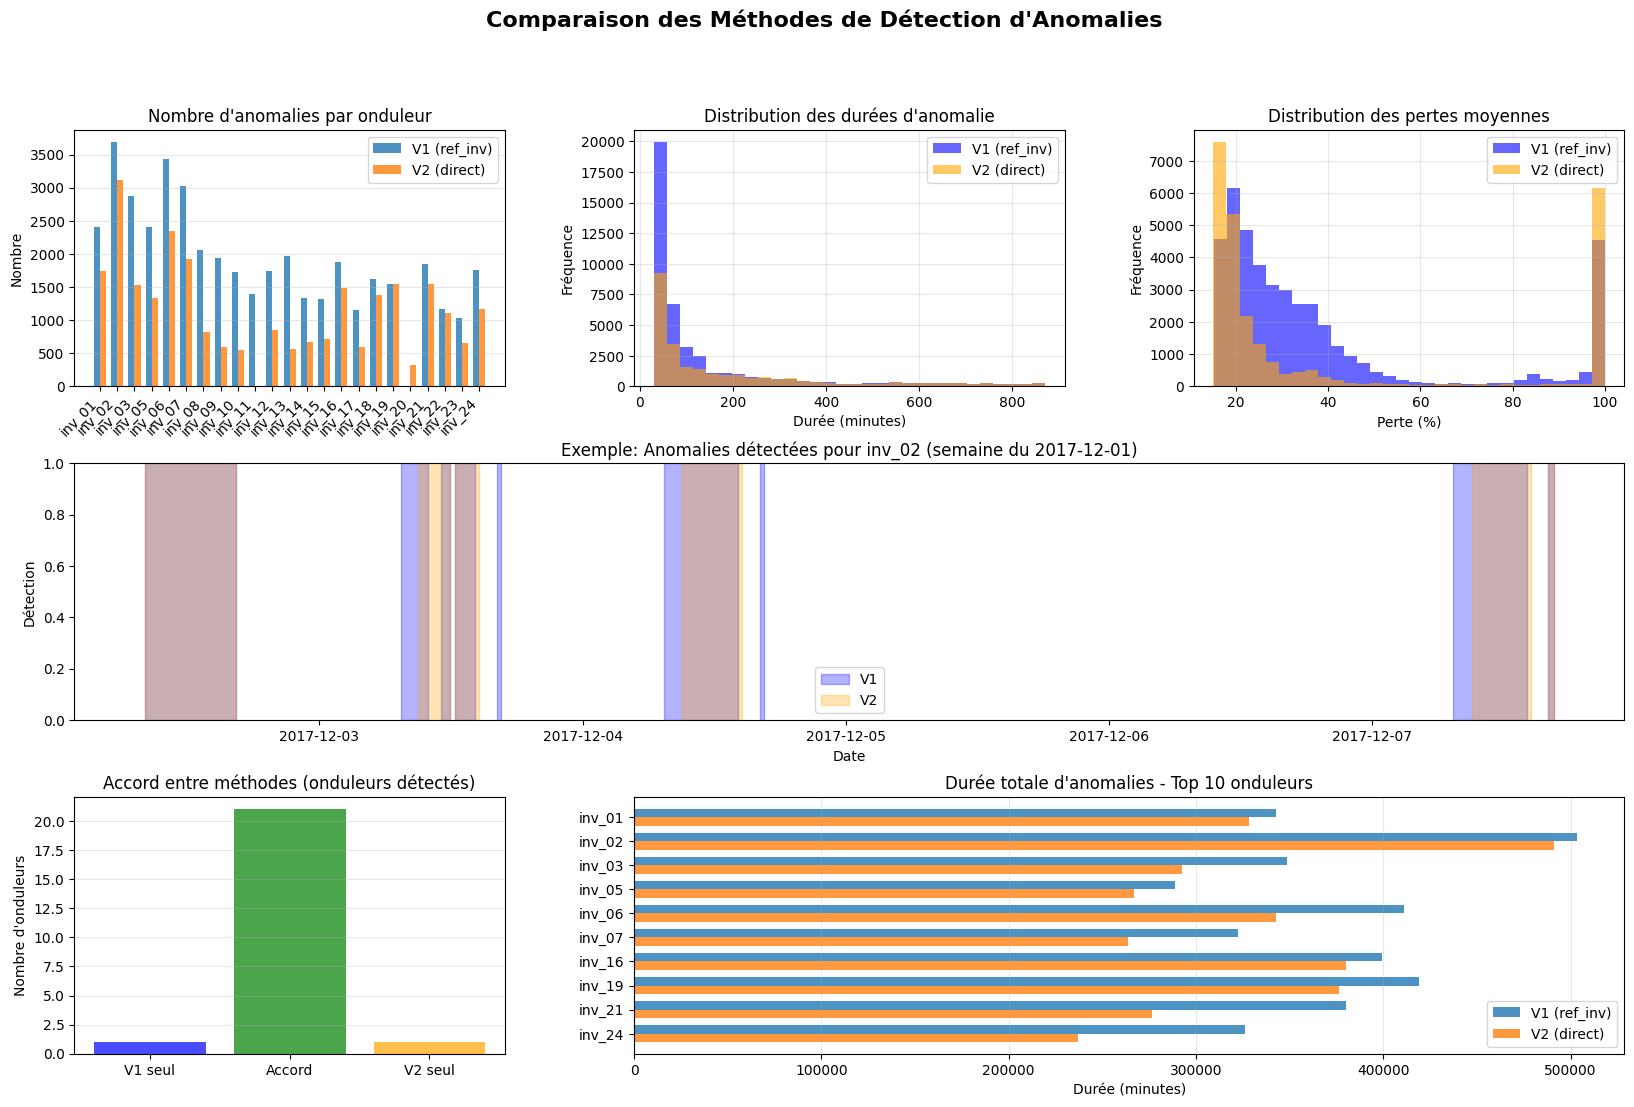

In [15]:

# ============================================================================
# EXÉCUTION
# ============================================================================

# À exécuter après avoir chargé df_clear et calculé reference_corrected
df_anom_v1, df_anom_v2 = compare_methods(
    df_clear, power_cols, inverter_ids,
    MIN_POWER_THRESHOLD_ADJUSTED, ANOMALY_THRESHOLD, MIN_DURATION
)